# Computing and data analysis project : Numerical modelling, the Shallow Water Equation
Jérémy BRICE / M2 - SCAHC / Report

# $\textcolor{blue}{Introduction}$

The numerical modeling of geophysical flows plays a central role in oceanography, coastal engineering, and environmental fluid dynamics. Many large-scale natural phenomena such as tides, storm surges, surface gravity waves, and river flows can be described by fluid motion where the horizontal scales are much larger than the vertical one. In such situations, the full three-dimensional Navier–Stokes equations can be simplified, leading to reduced models that remain physically relevant while being computationally more tractable.

Among these models, the shallow water equations, also known as the Saint-Venant equations, provide a fundamental framework to describe the horizontal motion of a free-surface fluid under the action of gravity. They are derived by vertically integrating the Navier–Stokes equations under the assumption of hydrostatic pressure and uniform velocity over the water depth. These equations are widely used to model wave propagation in oceans, lakes, rivers, and coastal regions, as well as for tsunami and flood simulations.

In this project, we focus on the linearized shallow water equations over a flat bottom and with constant mean water depth. This formulation is particularly well suited for studying surface gravity waves of small amplitude, where nonlinear effects and dissipative processes can be neglected. Under these assumptions, the system reduces to a set of coupled partial differential equations governing the horizontal velocity components and the free surface elevation.

The objective of this work is to investigate the numerical resolution of these equations and to analyze how different modeling choices affect stability, accuracy, and physical realism. Special attention is paid to the influence of the temporal integration scheme, the associated time step, and the treatment of boundary conditions. These aspects are known to play a crucial role in the quality of numerical solutions, especially when simulating wave propagation over long time intervals.

The study is first conducted in a one-dimensional framework, which allows for a clear analysis of numerical behavior and boundary effects. Several types of boundary conditions are explored, ranging from idealized periodic configurations to more realistic open-ocean and wall boundaries. The model is then extended to two dimensions, where a simplified coastal configuration is considered. This progression from 1D to 2D provides insight into the robustness and scalability of the numerical approach.

The equations governing the system are introduced in the following section, along with the assumptions underlying their derivation. Numerical discretization methods and boundary conditions are then presented, before discussing the results obtained in both one- and two-dimensional configurations.

# $\textcolor{blue}{Method}$

The Shallow Water Equations are : 

$$
\frac{\partial u}{\partial t}
+ u\,\frac{\partial u}{\partial x}
+ v\,\frac{\partial u}{\partial y}
+ g\,\frac{\partial \eta}{\partial x}
= \nu \nabla^{2} u
\tag{1.1}
$$

$$
\frac{\partial v}{\partial t}
+ u\,\frac{\partial v}{\partial x}
+ v\,\frac{\partial v}{\partial y}
+ g\,\frac{\partial \eta}{\partial y}
= \nu \nabla^{2} v
\tag{1.2}
$$

$$
\frac{\partial \eta}{\partial t}
+ \frac{\partial}{\partial x}\big[(H+\eta)\,u\big]
+ \frac{\partial}{\partial y}\big[(H+\eta)\,v\big]
= 0
\tag{1.3}
$$

With 𝑢 and 𝑣, respectively the zonal and meridional components of the velocity, 𝜂 the ocean free-surface height, H the depth and ν the kinematic viscosity of water.

### The Linearized One Dimensional Shallow Water Equations

If we suppose the dynamics to be
independent of y and if we further suppose $v = 0$ and that $H$ is constant, the shallow water
equations can be written as:


$$
\frac{\partial u}{\partial t}
+ u\,\frac{\partial u}{\partial x}
+ g\,\frac{\partial \eta}{\partial x}
= \nu \nabla^{2} u
\tag{2.1}
$$

$$
\frac{\partial \eta}{\partial t}
+ \frac{\partial}{\partial x}\big[(H+\eta)\,u\big]
= 0
\tag{2.2}
$$

If we further suppose that $u^2 ≪ g\eta$, that the viscosity $\nu \ll \frac{g \eta L}{u}$ and $\eta \ll H$ then :

$$
\frac{\partial u}{\partial t}
+ g\,\frac{\partial \eta}{\partial x} = 0
\tag{3.1}
$$

$$
\frac{\partial \eta}{\partial t}
+ H \frac{\partial u}{\partial x}
= 0
\tag{3.2}
$$

These equations can be modified to a single equation for η, it's the combined equation:  $\frac{\partial^2 \eta}{\partial t^2} = c^2 \frac{\partial^2 \eta}{\partial x^2}$ with $c = \sqrt{gH}$ the wave velocity.

### The Linearized Two Dimensional Shallow Water Equations

By linearizing the equations and making the same assumptions as those used in the one-dimensional case for viscosity and sea surface height, we obtain : 

$$
\frac{\partial u}{\partial t}
+ g\,\frac{\partial \eta}{\partial x}
= 0
\tag{4.1}
$$

$$
\frac{\partial v}{\partial t}
+ g\,\frac{\partial \eta}{\partial y}
= 0
\tag{4.2}
$$

$$
\frac{\partial \eta}{\partial t}
+ H \big[\frac{\partial u}{\partial x}
+ \frac{\partial v}{\partial y}\big]
= 0
\tag{4.3}
$$

These equations can be modified to a single equation for η :  $\frac{\partial^2 \eta}{\partial t^2} = c^2 \left( \frac{\partial^2 \eta}{\partial x^2} + \frac{\partial^2 \eta}{\partial y^2} \right)$

### Spatial scheme

The spatial derivatives are discretized using a centered finite difference scheme. This choice provides a good balance between accuracy and simplicity, as it is symmetric and does not introduce numerical bias in the direction of propagation.

For a variable 𝑢 defined on a uniform spatial grid with spacing $\Delta x$, it gives us :

$$
\left(\frac{\partial u}{\partial x}\right)_i^k
=
\frac{u_{i+1}^k - u_{i-1}^k}{2 \Delta x}.
$$

### Temporal schemes
#### Explicit Euler scheme

The explicit Euler scheme is used to discretize the time derivative. It allows a straightforward time integration but requires a sufficiently small time step to ensure numerical stability. The value at the next time step is calculated solely from the values known at the current time. For example, for 𝑢 this gives :

$$
\left(\frac{\partial u}{\partial t}\right)_i^k = \frac{u_{i}^{k+1} - u_{i}^k}{\Delta t} \Rightarrow u_{i}^{k+1} = u_{i}^k + \Delta t \left(\frac{\partial u}{\partial t}\right)_i^k
$$

#### Explicit fourth-order Runge-Kutta scheme

The explicit fourth-order Runge–Kutta scheme is used to discretize the time derivative with higher accuracy. It evaluates the time derivative at several intermediate stages within the time step, allowing a better approximation of the solution while maintaining explicit time integration. Compared to the explicit Euler scheme, it provides significantly improved accuracy and stability for a given time step, although at a higher computational cost. The value at the next time step is computed from a weighted average of these intermediate evaluations. For example, for 𝑢 this gives :

$$
f(u,t) = \frac{\partial u}{\partial t}
$$

$$
k_1 = f(u_i^k, t^k)
$$

$$
k_2 = f\Big(u_i^k + \frac{\Delta t}{2} k_1, t^k + \frac{\Delta t}{2}\Big)
$$

$$
k_3 = f\Big(u_i^k + \frac{\Delta t}{2} k_2, t^k + \frac{\Delta t}{2}\Big)
$$

$$
k_4 = f(u_i^k + \Delta t \, k_3, t^k + \Delta t)
$$

$$
u_i^{k+1} = u_i^k + \frac{\Delta t}{6} (k_1 + 2 k_2 + 2 k_3 + k_4)
$$

### Stability condition

For a centered explicit scheme, the stability condition is of CFL type:
$\mathrm{CFL} = c \cdot \frac{\Delta t}{\Delta x} \leq 1$ with $c = \sqrt{gH}$. The CFL number is a dimensionless quantity that compares the distance traveled by a wave during one time step to the spatial grid spacing.

### Boundary conditions

Boundary conditions in the numerical solution of partial differential equations can be chosen either to represent a specific physical situation or to handle numerical issues. In practice, a combination of both approaches is often used, especially when dealing with systems involving several variables, such as the shallow water equations.

#### Periodic boundary conditions

This boundary condition is particular because it involves both boundaries of the domain simultaneously. The idea is to directly link the two ends of the computational domain, which corresponds to periodic boundary conditions. This approach works well when waves propagate mainly in one direction and with similar speeds. However, it should be noted that this configuration is mainly intended for test cases, as it becomes less realistic when waves propagate in both directions and eventually interact or cross each other.
The periodic boundary conditions are applied to both variables, since applying them to only one would not be physically consistent. They are implemented as follows:

$$
\begin{cases}
u_{N+1} = u_1 \\
u_0 = u_N \\
\eta_{N+1} = \eta_1 \\
\eta_0 = \eta_N
\end{cases}
$$

#### Neumann boundary conditions

Neumann boundary conditions consist in prescribing the value of the spatial derivative of a variable at the boundary of the domain. In the most common case, this derivative is set to zero. This means that the variable does not vary in space at the boundary : the spatial gradient is zero.

##### Application to the velocity

For the velocity field, imposing a Neumann boundary condition with zero gradient means that the velocity at the boundary is equal to the velocity just inside the domain. Physically, this corresponds to a situation where there is no shear or constraint imposed at the boundary. In discrete form, this can be written as:

$$
u(0,t) = u(1,t), \quad u(N,t) = u(N-1,t)
$$

This type of condition can be interpreted as an open continuation of the flow outside the computational domain.

##### Application to the free surface elevation eta

The same reasoning can be applied to the free surface elevation. A zero-gradient Neumann condition for $\eta$ implies that the water surface is locally flat at the boundary. In discrete form:

$$
\eta(0,t) = \eta(1,t), \quad \eta(N,t) = \eta(N-1,t)
$$

This corresponds to an open boundary with no imposed slope of the free surface.

#### Mixed Boundary Conditions : Open Ocean and Wall

In more realistic configurations, different boundary conditions may be imposed on each side of the domain. A common setup consists of an open ocean boundary on one side and a solid wall on the other.

##### Open Ocean (Left Boundary)

At the open ocean boundary, a zero-gradient Neumann condition is imposed on both variables:

$$
u(0,t) = u(1,t), \quad \eta(0,t) = \eta(1,t)
$$

This allows waves and flow to leave or enter the domain without artificial reflection.

##### Impermeable Wall (Right Boundary)

An impermeable wall prevents fluid from crossing the boundary. This is modeled by imposing a zero velocity at the wall, while allowing the free surface to adjust freely.

$$
u(N,t) = 0, \quad \eta(N,t) = \eta(N-1,t)
$$

This boundary condition is a combination of Dirichlet and Neumann conditions:
- Dirichlet for the velocity $u$,
- Neumann for the free surface elevation $\eta$.

Physically, this represents a rigid wall against which the water can pile up but cannot flow through.

##### Perfectly Reflective Wall

A perfectly reflective wall can be modeled numerically by enforcing a symmetry of the velocity across the boundary:

$$
u(N,t) = -u(N-1,t), \quad \eta(N,t) = \eta(N-1,t)
$$

The condition on $u$ is neither purely Dirichlet nor Neumann. It ensures a reversal of the velocity at the boundary, leading to a full reflection of incoming waves.

### Additional Neumann-Type Conditions

Some boundary conditions can be interpreted as generalized Neumann conditions, where the derivative at the boundary is not zero but prescribed.

#### Free Surface Slope

To represent a sloping free surface, for instance to model a waterfall or imposed elevation gradient, the following condition can be used:

$$
\eta_0^n = \eta_1^n - \beta(t^n)
$$

where $\beta(t)$ represents the imposed slope of the free surface at the boundary.

#### Velocity Variation

To model an accelerating flow or a widening/narrowing channel, a similar condition can be imposed on the velocity :

$$
u_0^n = u_1^n - \alpha(t^n)
$$

where $\alpha(t)$ is a time-dependent function representing the imposed velocity variation.

#### Non-Zero Flux Condition

Finally, it is possible to impose a non-zero flux at the boundary, for example:

$$
u_0 = \Delta x \, s \, u_1
$$

This condition enforces a prescribed slope $s$ at the boundary and can represent a flowing channel. In such cases, the remaining variable can be obtained either through a simple Neumann condition or by using invariant-based methods.

# $\textcolor{blue}{General\ Set up}$

For the remainder of this study, a spatial resolution of **5 meters** is chosen, which provides good accuracy while keeping the computational cost reasonable. The stability condition defined previously therefore imposes a time step $\Delta t \leq 0.16 s$.  To ensure numerical stability over the entire simulation period, a time step of $\Delta t = 0.01 s$ is used for the first part of the study.

In [170]:
import numpy as np
from IPython.display import display, Math, Image
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import imageio
import io

In [171]:
#Time
Tsteps = 6000
dt = 0.01 # timestep [seconds]

#Space
dx = 5 # space step [meters]
dy = 5 
Xpoints = 200
Ypoints = 200
xrange = np.linspace(0,Xpoints*dx, Xpoints)
yrange = np.linspace(0,Ypoints*dx, Ypoints)

# constants
H = 100  #m
g = 9.81  #m/s^2

In [172]:
# initial condition ranges - where the gaussian bump is defined
start_x = 70
end_x = 130
start_y = 70
end_y = 130


def gaussian_1d(X, start_x, end_x):
    x = np.arange(X)
    mean = (start_x + end_x) / 2
    std_dev = (end_x - start_x) / 6
    return np.exp(-0.5 * ((x - mean) / std_dev) ** 2)

def gaussian_2d (X, Y, start_x, end_x, start_y, end_y):
    x = np.arange(X)
    y = np.arange(Y)
    mean_x = (start_x + end_x) / 2
    std_dev_x = (end_x - start_x) / 6
    mean_y = (start_y + end_y) / 2
    std_dev_y = (end_y - start_y) / 6
    X, Y = np.meshgrid(x, y, indexing='ij')
    return np.exp(-0.5 * (((X - mean_x) / std_dev_x) ** 2 +
                           ((Y - mean_y) / std_dev_y) ** 2))

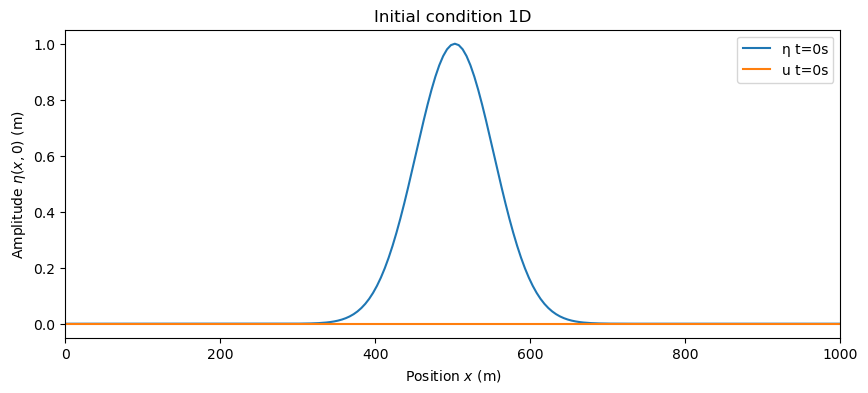

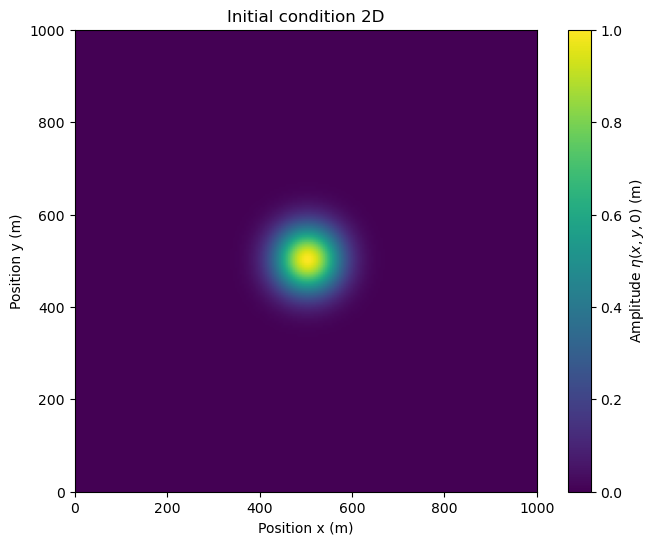

In [173]:
eta_0_1d = gaussian_1d(Xpoints, start_x, end_x)
eta_0_2d = gaussian_2d(Xpoints, Ypoints, start_x, end_x, start_y, end_y)
u_0 = np.zeros(Xpoints)

plt.figure(figsize=(10, 4))
plt.plot(xrange, eta_0_1d, label="η t=0s")
plt.plot(xrange, u_0, label="u t=0s")
plt.xlabel("Position $x$ (m)")
plt.ylabel("Amplitude $η(x, 0)$ (m)")
plt.title("Initial condition 1D")
plt.legend()
plt.xlim(0, 1000) 
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(eta_0_2d, extent=[0, Xpoints*dx, 0, Ypoints*dx], origin='lower', cmap='viridis')
plt.colorbar(label='Amplitude $η(x, y, 0)$ (m)')
plt.xlabel("Position x (m)")
plt.ylabel("Position y (m)")
plt.title("Initial condition 2D")
plt.show()

**Figure 1. Initial condition 1D :** Initial condition in one dimension for $\eta$ and $u$. The sea surface elevation, eta, is a smooth bell-shaped curve. The speed, u, is zero. This setup represents a perturbation in the form of a wave. Since the speed is zero, the water is initially "calm," allowing us to focus on the speed generated by the perturbation easily.

**Figure 2. Initial condition 2D :** Amplitude $\eta$ at $t=0$, it is the initial condition. It is represented as a bell-shaped curve in two dimensions, viewed from above. The speeds u and v are also equal to zero for the same reasons as in the one-dimensional case.

# $\textcolor{blue}{1D\ Centered\ Explicit\ Euler\ Scheme}$
## Periodic boundary conditions

In [174]:
def initialize_1D(eta_0_1d, u_0):
    # initializing
    eta = np.zeros([Tsteps, Xpoints])
    u  = np.zeros([Tsteps, Xpoints])
    # apply initial condition
    eta[0,:] = eta_0_1d
    u[0,:] = u_0
    return eta, u

In [175]:
def euler_1D_periodic(Tsteps, Xpoints, dt, dx, eta_0_1d, u_0):
    eta, u = initialize_1D(eta_0_1d, u_0)
    for k in range(Tsteps-1):
        for i in range(Xpoints):
            #periodic conditions
            ip = (i + 1) % Xpoints
            im = (i - 1) % Xpoints
            
            du_dx   = (u[k, ip] - u[k, im]) / (2*dx)
            deta_dx = (eta[k, ip] - eta[k, im]) / (2*dx)

            # update u
            u[k+1, i]   = u[k, i] - dt * (g * deta_dx)

            # update eta
            eta[k+1, i] = eta[k, i] - dt * (H * du_dx)
    return eta, u

In [176]:
def plot_eta_u(eta, u, xrange,  Tsteps, dt, times_to_plot):
    eta_disp = np.nan_to_num(eta, nan=0.0, posinf=0.0, neginf=0.0)
    u_disp   = np.nan_to_num(u,   nan=0.0, posinf=0.0, neginf=0.0)
    colors = plt.cm.tab10(np.linspace(0, 1, len(times_to_plot)))

    # Figure 1 : eta
    plt.figure(figsize=(10,5))
    for t_plot, col in zip(times_to_plot, colors):
        k = int(t_plot / dt)
        if k >= Tsteps:
            print(f"⚠️  Temps t={t_plot} s ignoré pour η")
            continue
        style = '-' if t_plot == 0 else '--'
        plt.plot(xrange,eta_disp[k, :],color=col,linestyle=style,linewidth=2,label=f"t = {t_plot:.0f} s")
    plt.xlabel("x (m)")
    plt.ylabel("η (m)")
    plt.title("η(x,t)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Figure 2 : u
    plt.figure(figsize=(10,5))
    for t_plot, col in zip(times_to_plot, colors):
        k = int(t_plot / dt)
        if k >= Tsteps:
            print(f"⚠️  Temps t={t_plot} s ignoré pour u")
            continue
        style = '-' if t_plot == 0 else '--'
        plt.plot(xrange,u_disp[k, :],color=col,linestyle=style,linewidth=2,label=f"t = {t_plot:.0f} s")
    plt.xlabel("x (m)")
    plt.ylabel("u (m/s)")
    plt.title("u(x,t)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [177]:
def gif_eta_u(eta, u, xrange, dt, step, fps):
    Tsteps = eta.shape[0]
    images = []

    for k in range(0, Tsteps, step):
        fig, axs = plt.subplots(1, 2, figsize=(12,4))
        
        #eta
        axs[0].plot(xrange, eta[k,:], color='blue')
        axs[0].set_ylim(np.min(eta)-0.1*np.abs(np.min(eta)), np.max(eta)+0.1*np.abs(np.max(eta)))
        axs[0].set_xlabel("x (m)")
        axs[0].set_ylabel("η (m)")
        axs[0].set_title(f"η(x,t), t={k*dt:.2f} s")
        axs[0].grid(True)
        
        #u
        axs[1].plot(xrange, u[k,:], color='red')
        axs[1].set_ylim(np.min(u)-0.1*np.abs(np.min(u)), np.max(u)+0.1*np.abs(np.max(u)))
        axs[1].set_xlabel("x (m)")
        axs[1].set_ylabel("u (m/s)")
        axs[1].set_title(f"u(x,t), t={k*dt:.2f} s")
        axs[1].grid(True)

        plt.tight_layout()
        fig.canvas.draw()
        image = np.array(fig.canvas.renderer.buffer_rgba())
        images.append(image)
        plt.close(fig)
        
    gif_bytes = io.BytesIO()
    imageio.mimsave(gif_bytes, images, format='GIF', fps=fps)
    gif_bytes.seek(0)
    display(Image(data=gif_bytes.read()))

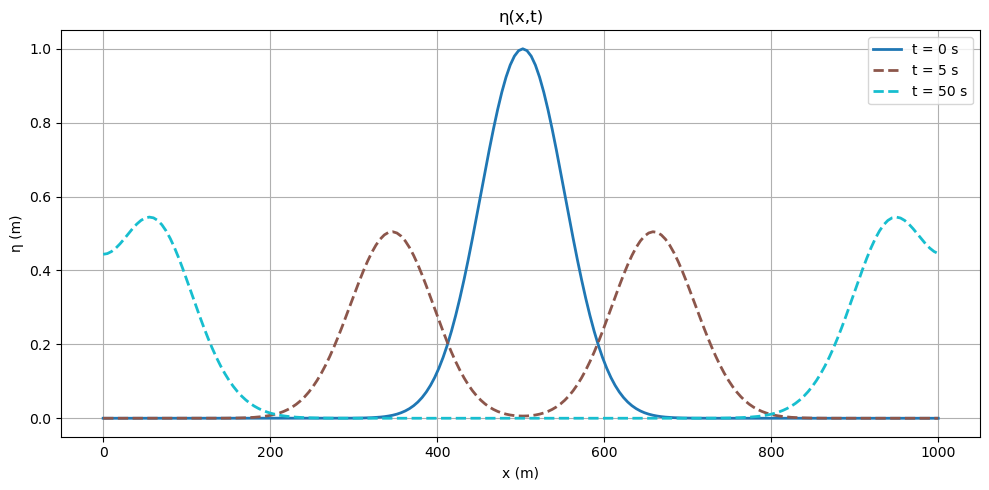

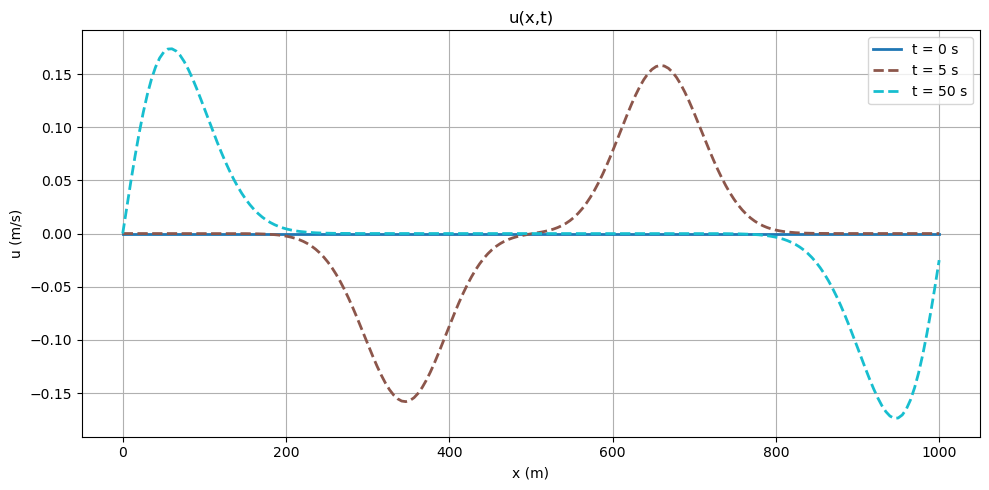

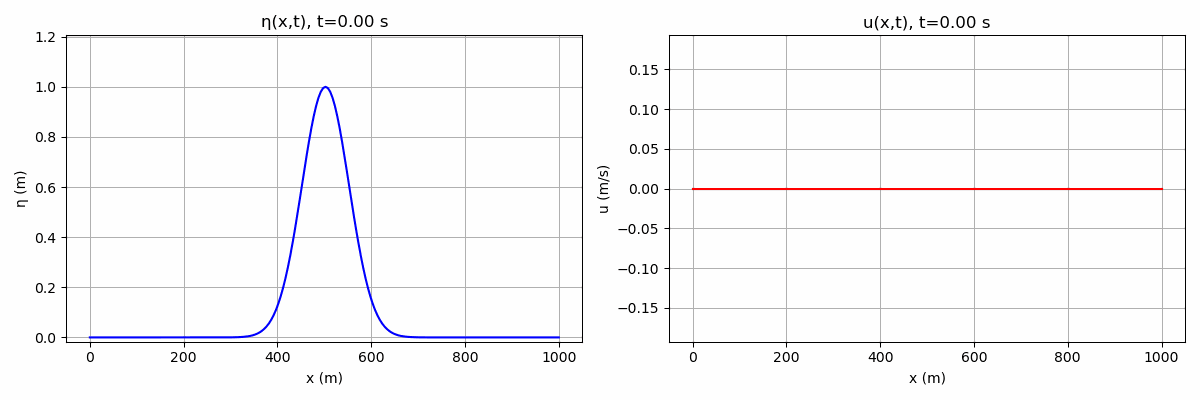

In [178]:
times_to_plot = [0, 5, 50]
eta, u = euler_1D_periodic(Tsteps, Xpoints, dt, dx, eta_0_1d, u_0)
plot_eta_u(eta, u, xrange,  Tsteps, dt, times_to_plot)
gif_eta_u(eta, u, xrange, dt, step=50, fps=2)

The centered explicit Euler scheme is very stable over at least the 60-second study period. The CFL-type stability condition required a choice of $\Delta t \leq 0.16 s$. Using $\Delta t = 0.1 s$ was not sufficient to ensure good stability over the simulation period, which is why $\Delta t = 0.01 s$ was chosen to guarantee proper stability. However, the fourth-order Runge-Kutta time scheme is much more stable and therefore allows the use of a larger time step. Indeed, if a time step more than four times larger than that chosen for the explicit Euler scheme is selected, the computational cost will be reduced. The goal is thus to optimize the computational cost depending on the choice of the time integration scheme and the associated time step. Care must be taken, however, to maintain adequate temporal resolution in order to possibly study the solution in fine detail over time.

# $\textcolor{blue}{1D\ Centered\ Explicit\ fourth\ order\ Runge\ Kutta\ Scheme}$
## Periodic boundary conditions

In [179]:
def rk4_1D_periodic(Tsteps, Xpoints, dt, dx, eta_01d, u_0, g, H):
    eta, u = initialize_1D(eta_0_1d, u_0)
    def dudt(u_arr, eta_arr, dx, g):
        X = len(u_arr)
        du = np.zeros_like(u_arr)
        for i in range(X):
            ip = (i + 1) % X
            im = (i - 1) % X
            du[i] = - g * (eta_arr[ip] - eta_arr[im]) / (2*dx)
        return du
    def detadt(u_arr, eta_arr, dx, H):
        X = len(u_arr)
        deta = np.zeros_like(eta_arr)
        for i in range(X):
            ip = (i + 1) % X
            im = (i - 1) % X
            deta[i] = - H * (u_arr[ip] - u_arr[im]) / (2*dx)
        return deta

    for k in range(Tsteps-1):
        # --- k1 ---
        k1_u   = dudt(u[k], eta[k], dx, g)
        k1_eta = detadt(u[k], eta[k], dx, H)

        # --- k2 ---
        u2   = u[k]   + 0.5 * dt * k1_u
        eta2 = eta[k] + 0.5 * dt * k1_eta
        k2_u   = dudt(u2, eta2, dx, g)
        k2_eta = detadt(u2, eta2, dx, H)

        # --- k3 ---
        u3   = u[k]   + 0.5 * dt * k2_u
        eta3 = eta[k] + 0.5 * dt * k2_eta
        k3_u   = dudt(u3, eta3, dx, g)
        k3_eta = detadt(u3, eta3, dx, H)

        # --- k4 ---
        u4   = u[k]   + dt * k3_u
        eta4 = eta[k] + dt * k3_eta
        k4_u   = dudt(u4, eta4, dx, g)
        k4_eta = detadt(u4, eta4, dx, H)

        u[k+1]   = u[k]   + (dt/6) * (k1_u + 2*k2_u + 2*k3_u + k4_u)
        eta[k+1] = eta[k] + (dt/6) * (k1_eta + 2*k2_eta + 2*k3_eta + k4_eta)

    return eta, u

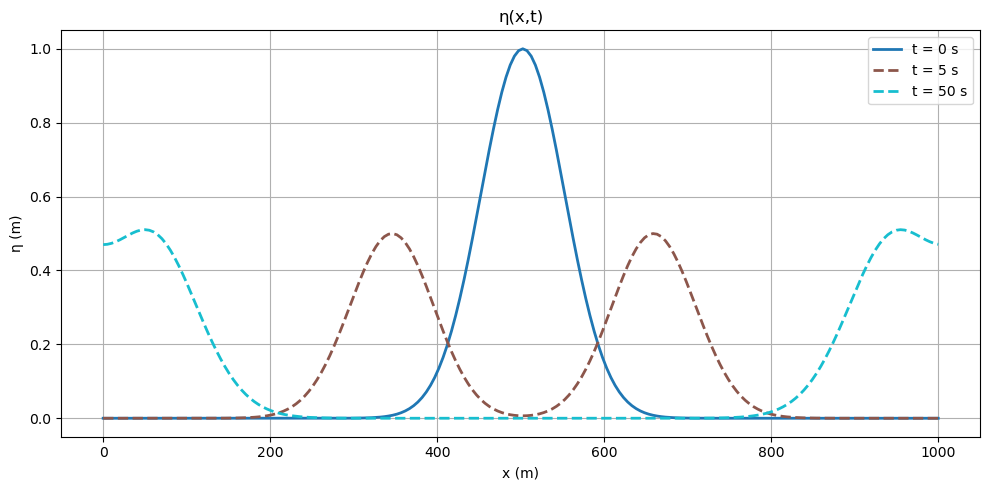

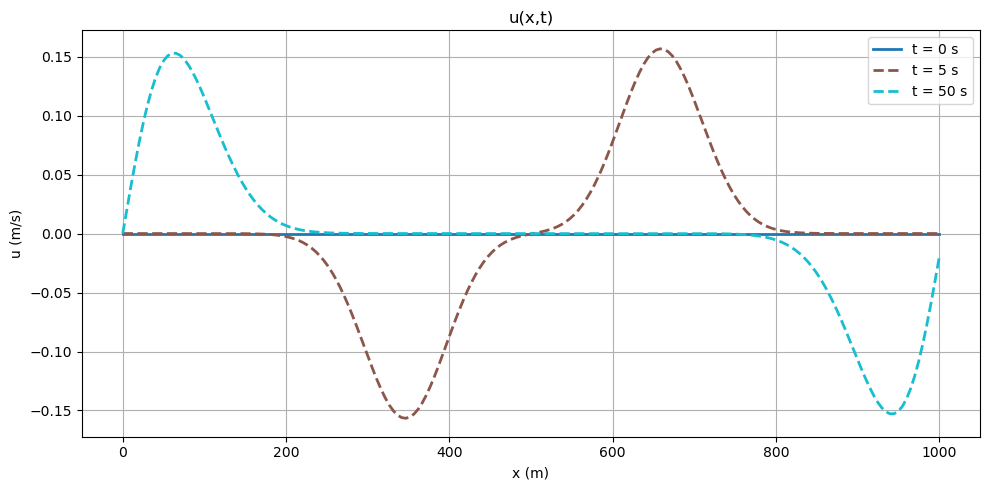

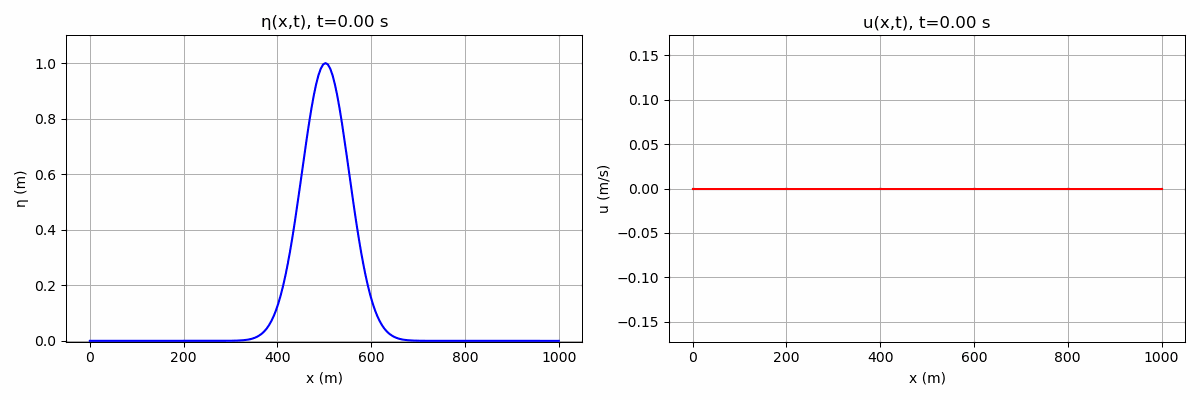

In [180]:
dt = 0.2 # new timestep
Tsteps = 300 # new number of timesteps to reach the 60s study period

times_to_plot = [0, 5, 50]
eta, u = rk4_1D_periodic(Tsteps, Xpoints, dt, dx, eta_0_1d, u_0, g, H)
plot_eta_u(eta, u, xrange,  Tsteps, dt, times_to_plot)
gif_eta_u(eta, u, xrange, dt, step=5, fps=4)

The fourth-order Runge-Kutta time scheme provides perfect stability over the study period by increasing the time step to $\Delta t = 0.2 s$, which is 20 times larger than that used for the explicit Euler scheme. This significantly reduces the computational cost while still maintaining good temporal resolution.

# $\textcolor{blue}{Exploring\ the\ boundary\ conditions\ 1D}$

The periodic boundary conditions chosen previously are not very realistic. For this reason, we will now explore different, more realistic boundary conditions that correspond to various real-life scenarios.

### Mixed Boundary Conditions : Open Ocean (left) and Wall (right)

The so-called “open ocean” boundary conditions impose a zero gradient for both the velocity and the free surface, allowing waves and flow to enter or leave the domain without artificial reflection. In contrast, an impermeable wall prevents water from crossing the boundary (zero velocity) while allowing the free surface to accumulate, physically representing a seawall or rigid barrier. A perfectly reflective wall reverses the velocity at the boundary while maintaining the surface height, reproducing a full reflection of incoming waves against a solid wall. In real-life situations, these conditions can respectively model a seawall or quay, and a vertical rigid wall where waves are fully reflected.

#### Impermeable Wall



In [181]:
def rk4_1D_open_wall1(Tsteps, Xpoints, dt, dx, eta_0, u_0, g, H):
    eta, u = initialize_1D(eta_0_1d, u_0)
    def dudt(u_arr, eta_arr):
        du = np.zeros_like(u_arr)
        for i in range(1, Xpoints-1):
            du[i] = - g * (eta_arr[i+1] - eta_arr[i-1]) / (2*dx)
        return du

    def detadt(u_arr, eta_arr):
        deta = np.zeros_like(eta_arr)
        for i in range(1, Xpoints-1):
            deta[i] = - H * (u_arr[i+1] - u_arr[i-1]) / (2*dx)
        return deta
        
    for k in range(Tsteps-1):
        # --- k1 ---
        k1_u   = dudt(u[k], eta[k])
        k1_eta = detadt(u[k], eta[k])

        # --- k2 ---
        u2   = u[k]   + 0.5 * dt * k1_u
        eta2 = eta[k] + 0.5 * dt * k1_eta
        k2_u   = dudt(u2, eta2)
        k2_eta = detadt(u2, eta2)

        # --- k3 ---
        u3   = u[k]   + 0.5 * dt * k2_u
        eta3 = eta[k] + 0.5 * dt * k2_eta
        k3_u   = dudt(u3, eta3)
        k3_eta = detadt(u3, eta3)

        # --- k4 ---
        u4   = u[k]   + dt * k3_u
        eta4 = eta[k] + dt * k3_eta
        k4_u   = dudt(u4, eta4)
        k4_eta = detadt(u4, eta4)

        u[k+1]   = u[k]   + (dt/6) * (k1_u + 2*k2_u + 2*k3_u + k4_u)
        eta[k+1] = eta[k] + (dt/6) * (k1_eta + 2*k2_eta + 2*k3_eta + k4_eta)

        # Left: Open Ocean (Neumann)
        u[k+1,0]   = u[k+1,1]
        eta[k+1,0] = eta[k+1,1]

        # Right: Impermeable Wall
        u[k+1,-1]   = 0
        eta[k+1,-1] = eta[k+1,-2]

    return eta, u

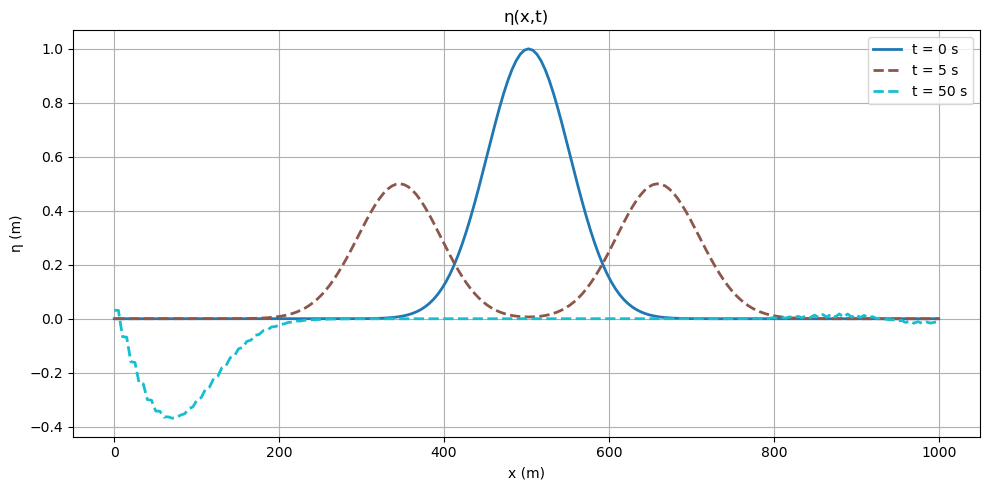

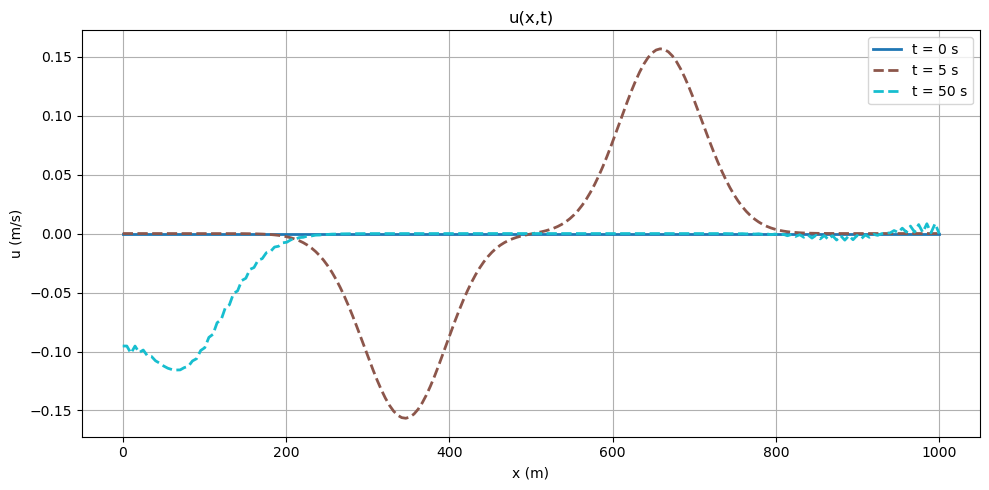

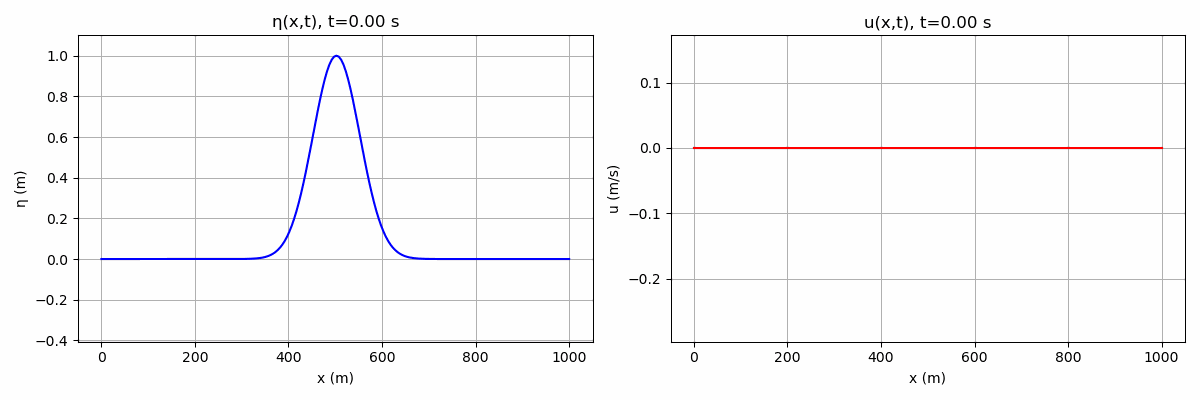

In [182]:
times_to_plot = [0, 5, 50]
eta, u = rk4_1D_open_wall1(Tsteps, Xpoints, dt, dx, eta_0_1d, u_0, g, H)
plot_eta_u(eta, u, xrange,  Tsteps, dt, times_to_plot)
gif_eta_u(eta, u, xrange, dt, step=5, fps=4)

#### Perfectly Reflective Wall

In [183]:
def rk4_1D_open_wall2(Tsteps, Xpoints, dt, dx, eta_0, u_0, g, H):
    eta, u = initialize_1D(eta_0_1d, u_0)
    def dudt(u_arr, eta_arr):
        du = np.zeros_like(u_arr)
        for i in range(1, Xpoints-1):
            du[i] = - g * (eta_arr[i+1] - eta_arr[i-1]) / (2*dx)
        return du

    def detadt(u_arr, eta_arr):
        deta = np.zeros_like(eta_arr)
        for i in range(1, Xpoints-1):
            deta[i] = - H * (u_arr[i+1] - u_arr[i-1]) / (2*dx)
        return deta
        
    for k in range(Tsteps-1):
        # --- k1 ---
        k1_u   = dudt(u[k], eta[k])
        k1_eta = detadt(u[k], eta[k])

        # --- k2 ---
        u2   = u[k]   + 0.5 * dt * k1_u
        eta2 = eta[k] + 0.5 * dt * k1_eta
        k2_u   = dudt(u2, eta2)
        k2_eta = detadt(u2, eta2)

        # --- k3 ---
        u3   = u[k]   + 0.5 * dt * k2_u
        eta3 = eta[k] + 0.5 * dt * k2_eta
        k3_u   = dudt(u3, eta3)
        k3_eta = detadt(u3, eta3)

        # --- k4 ---
        u4   = u[k]   + dt * k3_u
        eta4 = eta[k] + dt * k3_eta
        k4_u   = dudt(u4, eta4)
        k4_eta = detadt(u4, eta4)

        u[k+1]   = u[k]   + (dt/6) * (k1_u + 2*k2_u + 2*k3_u + k4_u)
        eta[k+1] = eta[k] + (dt/6) * (k1_eta + 2*k2_eta + 2*k3_eta + k4_eta)

        # Left: Open Ocean (Neumann)
        u[k+1,0]   = u[k+1,1]
        eta[k+1,0] = eta[k+1,1]

        # Right: Perfectly Reflective Wall
        u[k+1,-1]   = -u[k+1,-2]
        eta[k+1,-1] = eta[k+1,-2]

    return eta, u

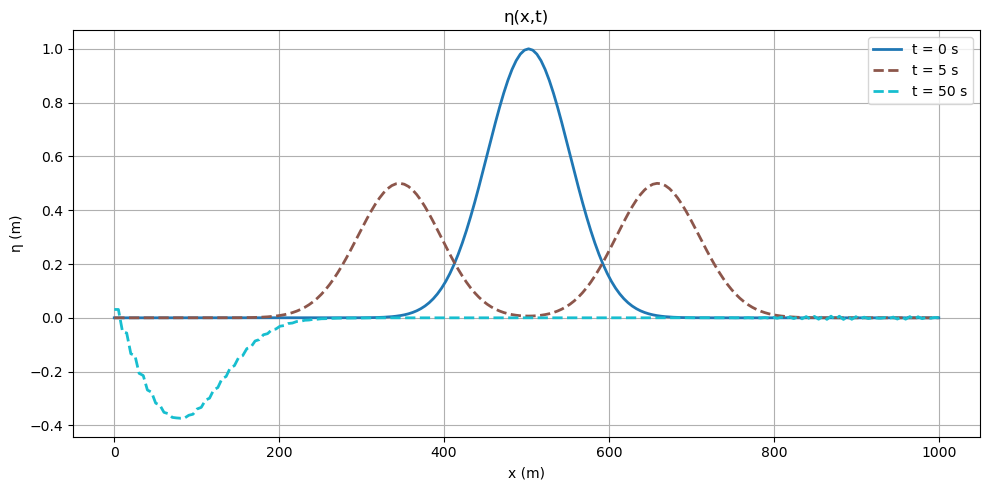

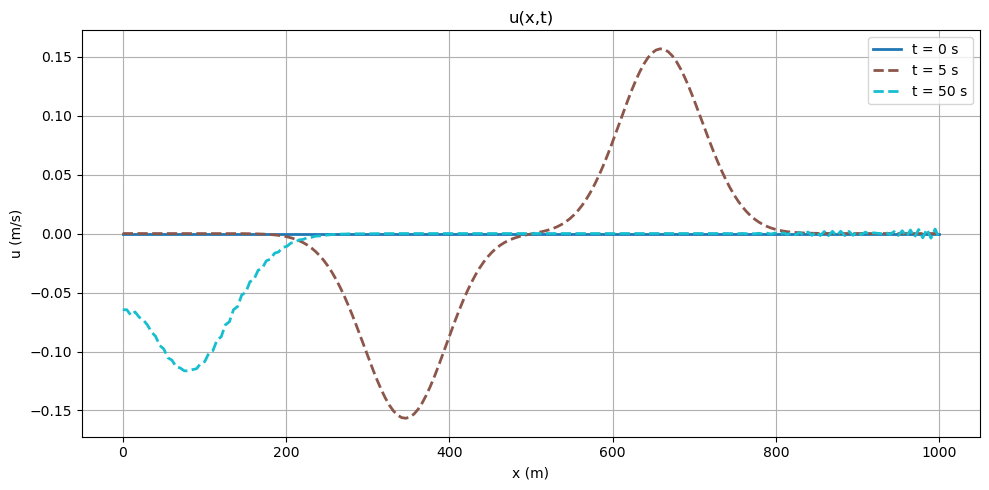

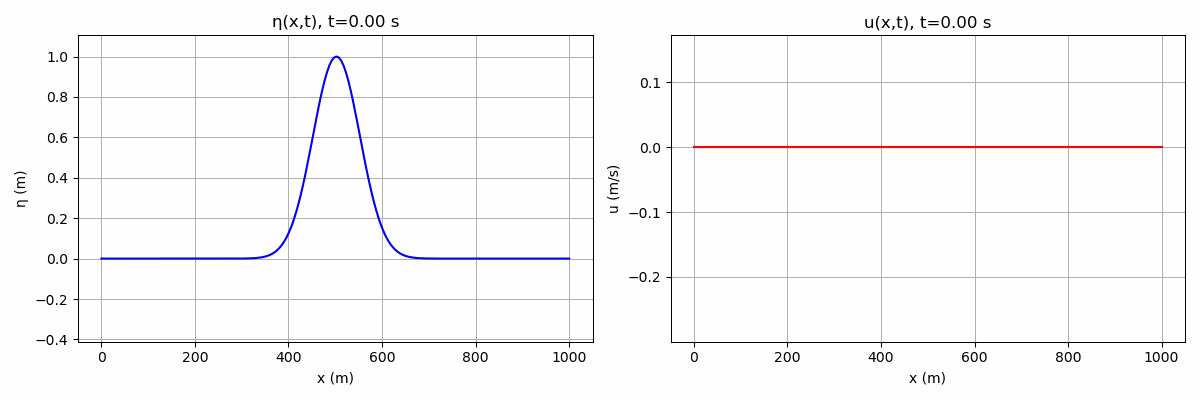

In [184]:
times_to_plot = [0, 5, 50]
eta, u = rk4_1D_open_wall2(Tsteps, Xpoints, dt, dx, eta_0_1d, u_0, g, H)
plot_eta_u(eta, u, xrange,  Tsteps, dt, times_to_plot)
gif_eta_u(eta, u, xrange, dt, step=5, fps=4)

We can observe that in both wall configurations, impermeable and perfectly reflective, the boundary conditions introduce small perturbations in both the velocity 𝑢 and the free surface elevation 𝜂. The wave is no longer perfectly smooth and small oscillations appear along its profile. These features should be interpreted as numerical perturbations induced by the boundary conditions rather than as a true numerical instability. The combination of a temporal scheme, a spatial discretization, and appropriate boundary conditions is essential to correctly resolve the shallow water equations. However, coupling these boundary conditions with a non-centered spatial scheme does not allow the problem to be solved satisfactorily. It is therefore necessary to investigate other boundary conditions corresponding to different real-world situations.

### Additional Neumann-Type Conditions

To further assess the influence of boundary conditions on the numerical solution, additional Neumann-type boundary conditions are introduced. Unlike classical zero-gradient conditions, these configurations impose a prescribed, non-zero gradient or variation at one boundary, allowing the system to be actively forced. Such conditions are physically meaningful and enable the modeling of more realistic situations, such as inflow-driven channels, imposed surface slopes, or steady fluxes. The response of the system is then analyzed while keeping a classical boundary condition at the opposite end of the domain.

#### Free Surface Slope and Wall

In this configuration, a free surface slope is imposed at the left boundary by prescribing $\eta_0 = \eta_1 - \beta$ with β=0.005 m. This condition enforces a lower free surface elevation at the boundary compared to the interior, which generates a pressure gradient directed from right to left. Physically, this setup represents a situation where water is drained or drawn out at the boundary, such as a downstream-controlled water level or a local drop in sea level. The right boundary is modeled as a solid wall, leading to wave reflection and an accumulation of water against the wall.

In [185]:
def rk4_1D_A(Tsteps, Xpoints, dt, dx, eta_0_1d, u_0, g, H, beta):
    eta, u = initialize_1D(eta_0_1d, u_0)

    def dudt(u_arr, eta_arr):
        du = np.zeros_like(u_arr)
        for i in range(1, Xpoints-1):
            du[i] = -g * (eta_arr[i+1] - eta_arr[i-1]) / (2*dx)
        return du

    def detadt(u_arr, eta_arr):
        deta = np.zeros_like(eta_arr)
        for i in range(1, Xpoints-1):
            deta[i] = -H * (u_arr[i+1] - u_arr[i-1]) / (2*dx)
        return deta

    for k in range(Tsteps-1):
        k1_u   = dudt(u[k], eta[k])
        k1_eta = detadt(u[k], eta[k])

        u2   = u[k]   + 0.5*dt*k1_u
        eta2 = eta[k] + 0.5*dt*k1_eta
        k2_u   = dudt(u2, eta2)
        k2_eta = detadt(u2, eta2)

        u3   = u[k]   + 0.5*dt*k2_u
        eta3 = eta[k] + 0.5*dt*k2_eta
        k3_u   = dudt(u3, eta3)
        k3_eta = detadt(u3, eta3)

        u4   = u[k]   + dt*k3_u
        eta4 = eta[k] + dt*k3_eta
        k4_u   = dudt(u4, eta4)
        k4_eta = detadt(u4, eta4)

        u[k+1]   = u[k]   + (dt/6)*(k1_u + 2*k2_u + 2*k3_u + k4_u)
        eta[k+1] = eta[k] + (dt/6)*(k1_eta + 2*k2_eta + 2*k3_eta + k4_eta)

        # Left: imposed free surface slope
        eta[k+1,0] = eta[k+1,1] - beta
        u[k+1,0]   = u[k+1,1]

        # Right: reflective wall
        u[k+1,-1]   = -u[k+1,-2]
        eta[k+1,-1] = eta[k+1,-2]

    return eta, u

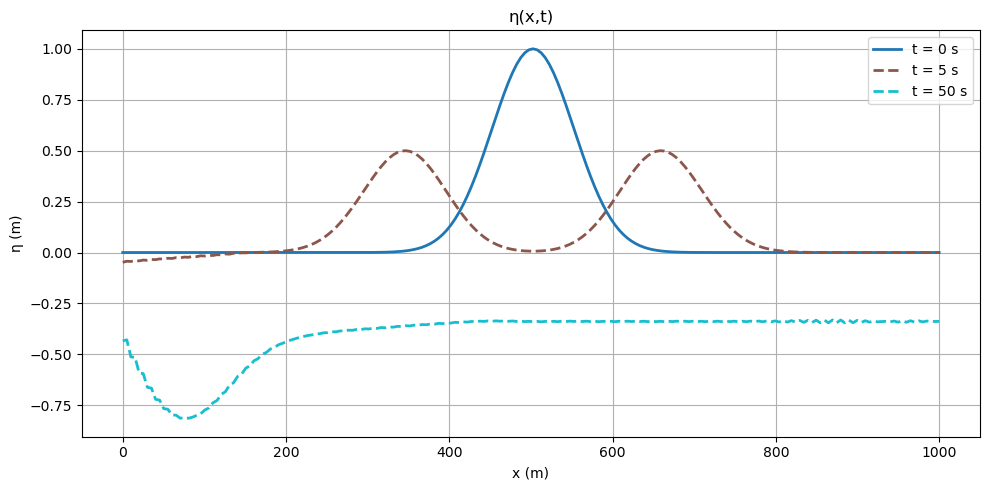

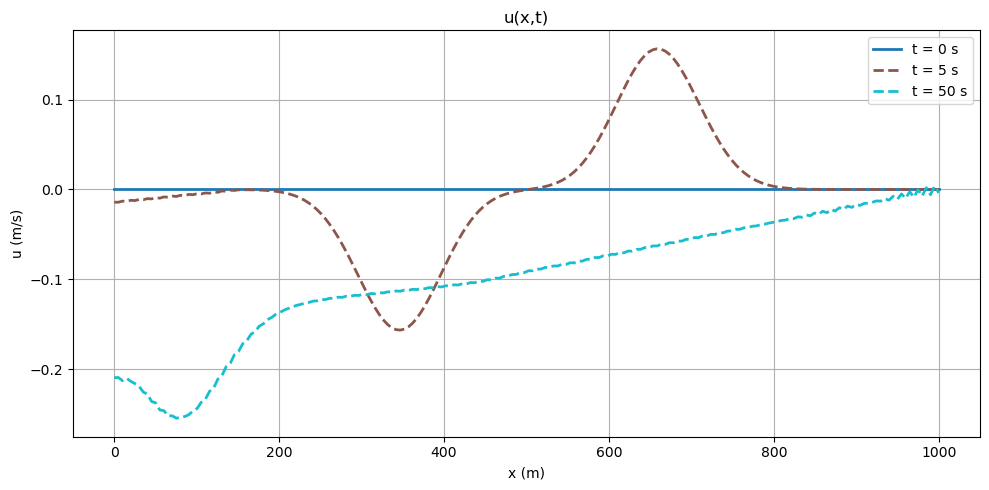

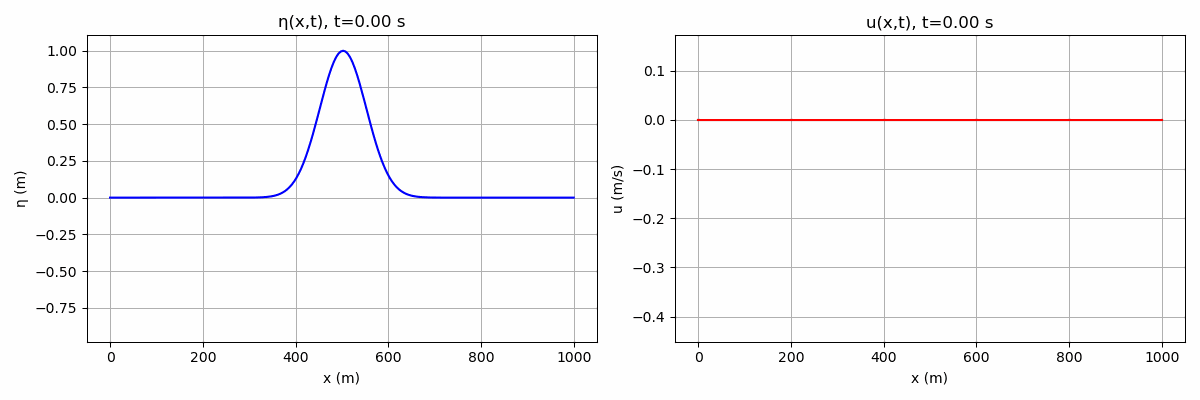

In [186]:
times_to_plot = [0, 5, 50]
eta, u = rk4_1D_A(Tsteps, Xpoints, dt, dx, eta_0_1d, u_0, g, H, beta = 0.005)
plot_eta_u(eta, u, xrange,  Tsteps, dt, times_to_plot)
gif_eta_u(eta, u, xrange, dt, step=5, fps=4)

### Velocity Variation and Open Ocean

In this case, a velocity variation is imposed at the left boundary through $u_0 = u_1 - \alpha$ with α=0.01. This condition enforces a reduction of the velocity at the left boundary, inducing a flow directed out of the domain on that side. Physically, this configuration can represent a controlled outflow or a sink, such as water leaving a channel or a region where flow is extracted. At the right boundary, an open ocean condition is imposed, allowing waves and flow to exit the domain without significant artificial reflection. As a result, disturbances generated near the left boundary can propagate through the domain and leave it smoothly, leading to a more realistic representation of an open system driven by a boundary forcing.

In [187]:
def rk4_1D_B(Tsteps, Xpoints, dt, dx, eta_0_1d, u_0, g, H, alpha):
    eta, u = initialize_1D(eta_0_1d, u_0)

    def dudt(u_arr, eta_arr):
        du = np.zeros_like(u_arr)
        for i in range(1, Xpoints-1):
            du[i] = -g * (eta_arr[i+1] - eta_arr[i-1]) / (2*dx)
        return du

    def detadt(u_arr, eta_arr):
        deta = np.zeros_like(eta_arr)
        for i in range(1, Xpoints-1):
            deta[i] = -H * (u_arr[i+1] - u_arr[i-1]) / (2*dx)
        return deta

    for k in range(Tsteps-1):
        k1_u   = dudt(u[k], eta[k])
        k1_eta = detadt(u[k], eta[k])

        u2   = u[k]   + 0.5*dt*k1_u
        eta2 = eta[k] + 0.5*dt*k1_eta
        k2_u   = dudt(u2, eta2)
        k2_eta = detadt(u2, eta2)

        u3   = u[k]   + 0.5*dt*k2_u
        eta3 = eta[k] + 0.5*dt*k2_eta
        k3_u   = dudt(u3, eta3)
        k3_eta = detadt(u3, eta3)

        u4   = u[k]   + dt*k3_u
        eta4 = eta[k] + dt*k3_eta
        k4_u   = dudt(u4, eta4)
        k4_eta = detadt(u4, eta4)

        u[k+1]   = u[k]   + (dt/6)*(k1_u + 2*k2_u + 2*k3_u + k4_u)
        eta[k+1] = eta[k] + (dt/6)*(k1_eta + 2*k2_eta + 2*k3_eta + k4_eta)

        # Left: velocity variation
        u[k+1,0]   = u[k+1,1] - alpha
        eta[k+1,0] = eta[k+1,1]
        
        # Right: open ocean
        u[k+1,-1]   = u[k+1,-2]
        eta[k+1,-1] = eta[k+1,-2]

    return eta, u

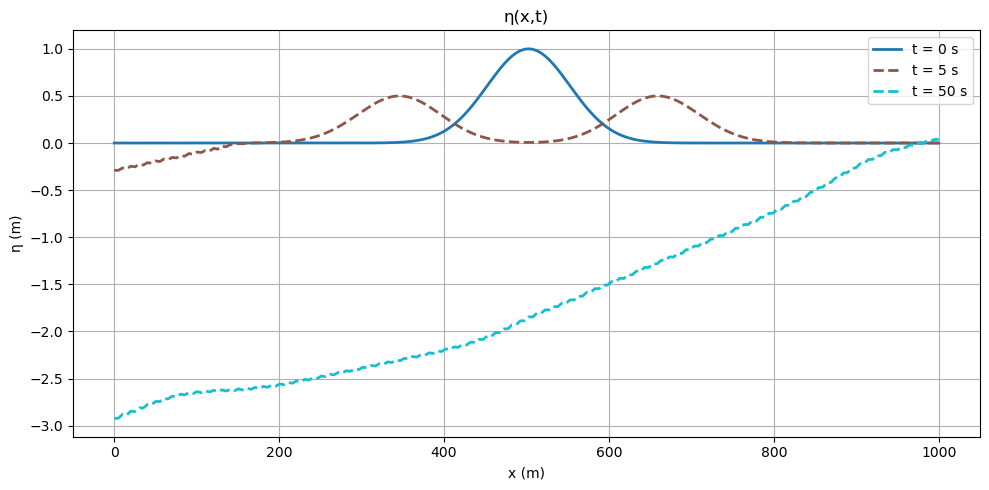

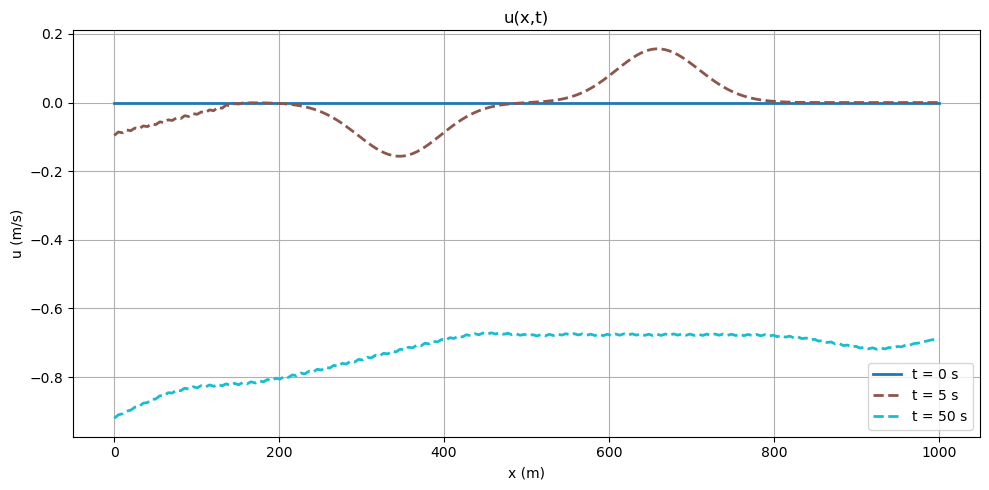

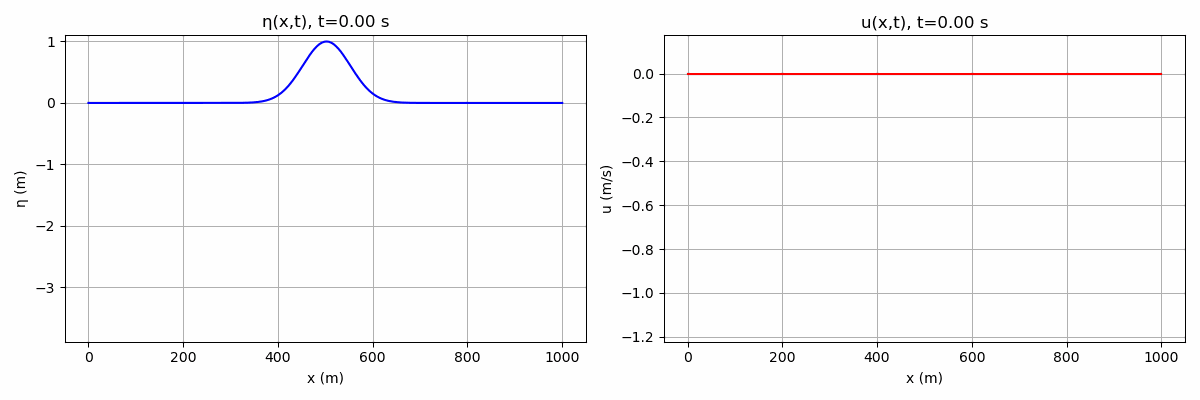

In [188]:
times_to_plot = [0, 5, 50]
eta, u = rk4_1D_B(Tsteps, Xpoints, dt, dx, eta_0_1d, u_0, g, H, alpha = 0.01)
plot_eta_u(eta, u, xrange,  Tsteps, dt, times_to_plot)
gif_eta_u(eta, u, xrange, dt, step=5, fps=4)

### Non-Zero Flux and Open Ocean 

In this case, a non-zero flux condition is imposed at the left boundary according to $u_0 = \Delta x s u_1$ with $s = 0.21 m^{-1}$ so that $\Delta x s = 1.05$. This condition enforces a prescribed velocity amplification at the boundary and therefore introduces a continuous momentum flux into the computational domain. Physically, this configuration represents a forced inflow, such as water entering a channel due to an imposed upstream discharge. Because the imposed velocity is proportional to the interior velocity, any existing flow near the boundary is progressively amplified. As a result, the velocity magnitude increases close to the left boundary as the simulation evolves, and a corresponding adjustment of the free surface elevation is observed through the continuity equation. The right boundary is treated as an open ocean, allowing waves and flow to exit the domain without artificial reflection. This setup models an open, driven system in which mass and momentum are continuously injected at one boundary and freely propagate out of the domain.

In [189]:
def rk4_1D_C(Tsteps, Xpoints, dt, dx, eta_0_1d, u_0, g, H, s):
    eta, u = initialize_1D(eta_0_1d, u_0)

    def dudt(u_arr, eta_arr):
        du = np.zeros_like(u_arr)
        for i in range(1, Xpoints-1):
            du[i] = -g * (eta_arr[i+1] - eta_arr[i-1]) / (2*dx)
        return du

    def detadt(u_arr, eta_arr):
        deta = np.zeros_like(eta_arr)
        for i in range(1, Xpoints-1):
            deta[i] = -H * (u_arr[i+1] - u_arr[i-1]) / (2*dx)
        return deta

    for k in range(Tsteps-1):
        k1_u   = dudt(u[k], eta[k])
        k1_eta = detadt(u[k], eta[k])

        u2   = u[k]   + 0.5*dt*k1_u
        eta2 = eta[k] + 0.5*dt*k1_eta
        k2_u   = dudt(u2, eta2)
        k2_eta = detadt(u2, eta2)

        u3   = u[k]   + 0.5*dt*k2_u
        eta3 = eta[k] + 0.5*dt*k2_eta
        k3_u   = dudt(u3, eta3)
        k3_eta = detadt(u3, eta3)

        u4   = u[k]   + dt*k3_u
        eta4 = eta[k] + dt*k3_eta
        k4_u   = dudt(u4, eta4)
        k4_eta = detadt(u4, eta4)

        u[k+1]   = u[k]   + (dt/6)*(k1_u + 2*k2_u + 2*k3_u + k4_u)
        eta[k+1] = eta[k] + (dt/6)*(k1_eta + 2*k2_eta + 2*k3_eta + k4_eta)

        # Left: non-zero flux
        u[k+1,0]   = dx * s * u[k+1,1]
        eta[k+1,0] = eta[k+1,1]
        
        # Right: open ocean
        u[k+1,-1]   = u[k+1,-2]
        eta[k+1,-1] = eta[k+1,-2]

    return eta, u

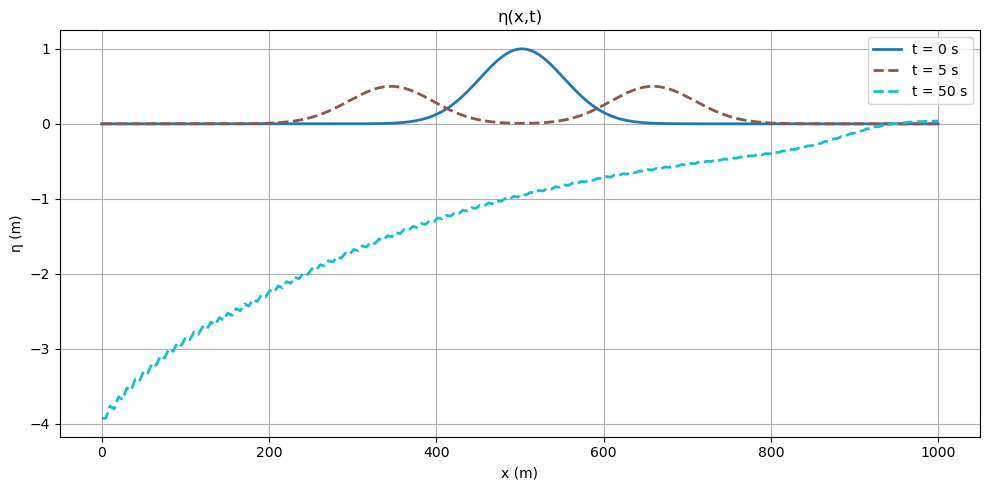

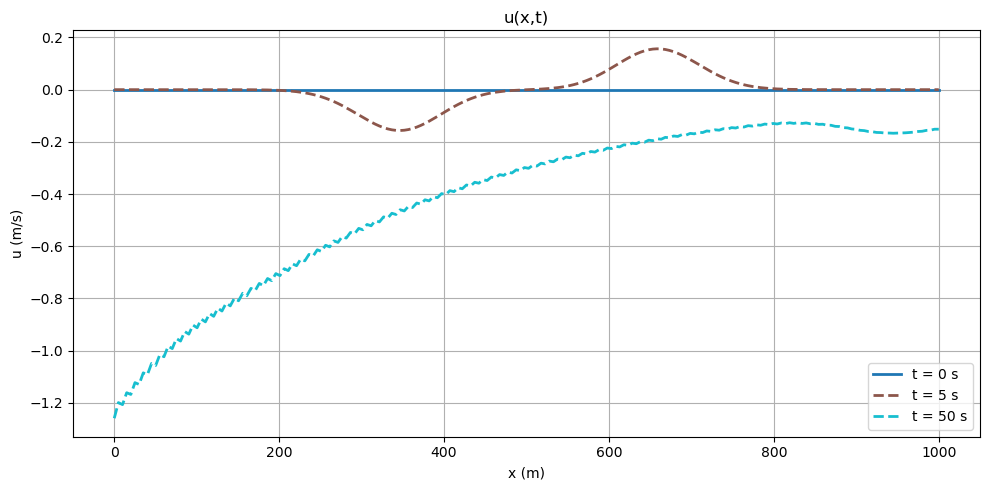

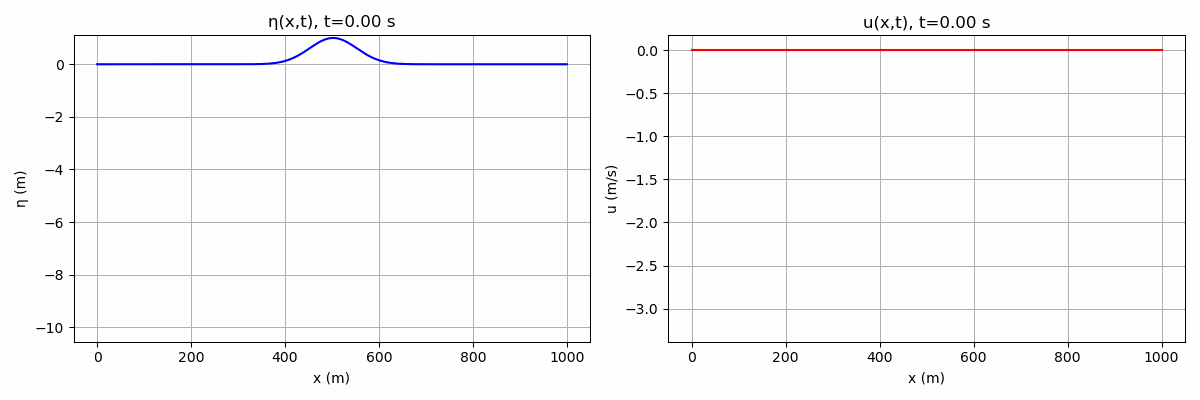

In [190]:
times_to_plot = [0, 5, 50]
eta, u = rk4_1D_C(Tsteps, Xpoints, dt, dx, eta_0_1d, u_0, g, H, s = 0.21)
plot_eta_u(eta, u, xrange,  Tsteps, dt, times_to_plot)
gif_eta_u(eta, u, xrange, dt, step=5, fps=4)

Overall, the new boundary conditions named the free surface slope, velocity variation, and non-zero flux, do not completely eliminate the small perturbations in velocity and free surface elevation that were already present with the previous open ocean and wall configurations. However, these perturbations are very minor and do not significantly affect the solution, allowing for accurate resolution of the shallow water dynamics despite the boundary-induced effects.

Having analyzed the influence of various boundary conditions in 1D, as well as the effect of the temporal scheme and associated time step on computational cost and stability, we now extend the study to two-dimensional flows.

# $\textcolor{blue}{2D\ Centered\ Explicit\ fourth\ order\ Runge\ Kutta\ Scheme}$

Based on our observations in the 1D study, the extension to 2D is performed using a centered fourth-order Runge-Kutta scheme with the same time step, providing both numerical stability and a high spatial and temporal resolution of the shallow water equations, while using the same initial parameters as in the 1D simulations, now applied across both spatial dimensions.

For the boundary conditions in 2D, we choose a realistic case previously studied in 1D, now extended to two dimensions. Along the 𝑥-direction, we impose an open ocean boundary on the left and a perfectly reflective wall on the right, while along the 𝑦-direction both boundaries are treated as open ocean. Physically, this setup can be interpreted as representing a coastal region: the left boundary mimics the open ocean allowing waves and flow to enter freely, while the right boundary represents a solid coast where waves are reflected. The open boundaries along 𝑦 allow the flow to propagate freely in the transverse direction.

In [191]:
def initialize_2D(eta_0_2d, u_0, Tsteps, Xpoints, Ypoints):
    eta = np.zeros([Tsteps, Xpoints, Ypoints])
    u   = np.zeros([Tsteps, Xpoints, Ypoints])
    v   = np.zeros([Tsteps, Xpoints, Ypoints])

    eta[0,:,:] = eta_0_2d
    u[0,:,:]   = u_0
    v[0,:,:]   = u_0
    return eta, u, v

def rk4_2D_open_wall(Tsteps, Xpoints, Ypoints, dt, dx, dy, eta_0_2d, u_0, g, H):
    eta, u, v = initialize_2D(eta_0_2d, u_0, Tsteps, Xpoints, Ypoints)

    def dudt(u_arr, eta_arr):
        du = np.zeros_like(u_arr)
        for i in range(1, Xpoints-1):
            for j in range(1, Ypoints-1):
                du_dx = (eta_arr[i+1, j] - eta_arr[i-1, j]) / (2*dx)
                du[i,j] = - g * du_dx
        return du
    
    def dvdt(v_arr, eta_arr):
        dv = np.zeros_like(v_arr)
        for i in range(1, Xpoints-1):
            for j in range(1, Ypoints-1):
                dv_dy = (eta_arr[i, j+1] - eta_arr[i, j-1]) / (2*dy)
                dv[i,j] = - g * dv_dy
        return dv
    
    def detadt(u_arr, v_arr):
        deta = np.zeros_like(u_arr)
        for i in range(1, Xpoints-1):
            for j in range(1, Ypoints-1):
                du_dx = (u_arr[i+1,j] - u_arr[i-1,j]) / (2*dx)
                dv_dy = (v_arr[i,j+1] - v_arr[i,j-1]) / (2*dy)
                deta[i,j] = - H * (du_dx + dv_dy)
        return deta

    for k in range(Tsteps-1):
        # --- k1 ---
        k1_u   = dudt(u[k], eta[k])
        k1_v   = dvdt(v[k], eta[k])
        k1_eta = detadt(u[k], v[k])
        
        # --- k2 ---
        u2   = u[k]   + 0.5 * dt * k1_u
        v2   = v[k]   + 0.5 * dt * k1_v
        eta2 = eta[k] + 0.5 * dt * k1_eta
        k2_u   = dudt(u2, eta2)
        k2_v   = dvdt(v2, eta2)
        k2_eta = detadt(u2, v2)
        
        # --- k3 ---
        u3   = u[k]   + 0.5 * dt * k2_u
        v3   = v[k]   + 0.5 * dt * k2_v
        eta3 = eta[k] + 0.5 * dt * k2_eta
        k3_u   = dudt(u3, eta3)
        k3_v   = dvdt(v3, eta3)
        k3_eta = detadt(u3, v3)
        
        # --- k4 ---
        u4   = u[k]   + dt * k3_u
        v4   = v[k]   + dt * k3_v
        eta4 = eta[k] + dt * k3_eta
        k4_u   = dudt(u4, eta4)
        k4_v   = dvdt(v4, eta4)
        k4_eta = detadt(u4, v4)
        
        u[k+1]   = u[k]   + (dt/6) * (k1_u + 2*k2_u + 2*k3_u + k4_u)
        v[k+1]   = v[k]   + (dt/6) * (k1_v + 2*k2_v + 2*k3_v + k4_v)
        eta[k+1] = eta[k] + (dt/6) * (k1_eta + 2*k2_eta + 2*k3_eta + k4_eta)
        
        # --- Boundary conditions ---
        # Left: Open Ocean (Neumann)
        u[k+1,0,:]   = u[k+1,1,:]
        v[k+1,0,:]   = v[k+1,1,:]
        eta[k+1,0,:] = eta[k+1,1,:]
        
        # Right: Perfectly Reflective Wall
        u[k+1,-1,:]   = -u[k+1,-2,:]
        v[k+1,-1,:]   = v[k+1,-2,:]
        eta[k+1,-1,:] = eta[k+1,-2,:]
        
        # Top and bottom : Open Ocean (Neumann)
        u[k+1,:,0]   = u[k+1,:,1]
        u[k+1,:,-1]  = u[k+1,:,-2]
        v[k+1,:,0]   = v[k+1,:,1]
        v[k+1,:,-1]  = v[k+1,:,-2]
        eta[k+1,:,0] = eta[k+1,:,1]
        eta[k+1,:,-1]= eta[k+1,:,-2]
    
    return eta, u, v

def plot_eta_uv_2D(eta, u, v, x, y, dt, times_to_plot, skip=5, scale=2, ncols=2):
    n_plots = len(times_to_plot)
    nrows = int(np.ceil(n_plots / ncols))
    Xgrid, Ygrid = np.meshgrid(x, y)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
    for idx, t_plot in enumerate(times_to_plot):
        k = int(t_plot / dt)
        if k >= eta.shape[0]:
            print(f"⚠️ Time t={t_plot} s ignored")
            continue
        eta_plot = eta[k, :, :].T
        u_plot   = u[k, :, :].T
        v_plot   = v[k, :, :].T
        row = idx // ncols
        col = idx % ncols
        ax = axes[row, col]
        im = ax.imshow(eta_plot,origin='lower',extent=[x[0], x[-1], y[0], y[-1]],cmap='RdBu_r',vmin=-0.5,vmax=0.5)
        ax.quiver(Xgrid[::skip, ::skip],Ygrid[::skip, ::skip],u_plot[::skip, ::skip],v_plot[::skip, ::skip],scale=scale,color='k')
        ax.set_title(f"t = {t_plot:.1f} s")
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("η (m)")
    for idx_empty in range(n_plots, nrows*ncols):
        row = idx_empty // ncols
        col = idx_empty % ncols
        fig.delaxes(axes[row, col])
    plt.tight_layout()
    plt.show()

def gif_eta_uv_2D(eta, u, v, x, y, dt, step=1, fps=10, skip=5, scale=2):
    Tsteps = eta.shape[0]
    images = []
    Xgrid, Ygrid = np.meshgrid(x, y)
    for k in range(0, Tsteps, step):
        fig, ax = plt.subplots(figsize=(6,5))
        eta_plot = eta[k, :, :].T
        u_plot   = u[k, :, :].T
        v_plot   = v[k, :, :].T
        im = ax.imshow(eta_plot,origin="lower",extent=[x[0], x[-1], y[0], y[-1]],cmap="RdBu_r",vmin=-0.5,vmax=0.5)
        ax.quiver(Xgrid[::skip, ::skip],Ygrid[::skip, ::skip],u_plot[::skip, ::skip],v_plot[::skip, ::skip],scale=scale,color="k")
        ax.set_title(f"t = {k*dt:.2f} s")
        ax.set_xlabel("x (m)")
        ax.set_ylabel("y (m)")
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("η (m)")
        plt.tight_layout()
        fig.canvas.draw()
        image = np.array(fig.canvas.renderer.buffer_rgba())
        images.append(image)
        plt.close(fig)
    gif_bytes = io.BytesIO()
    imageio.mimsave(gif_bytes, images, format="GIF", fps=fps)
    gif_bytes.seek(0)
    display(Image(data=gif_bytes.read()))

In [192]:
eta, u, v = rk4_2D_open_wall(Tsteps, Xpoints, Ypoints, dt, dx, dy, eta_0_2d, u_0, g, H)

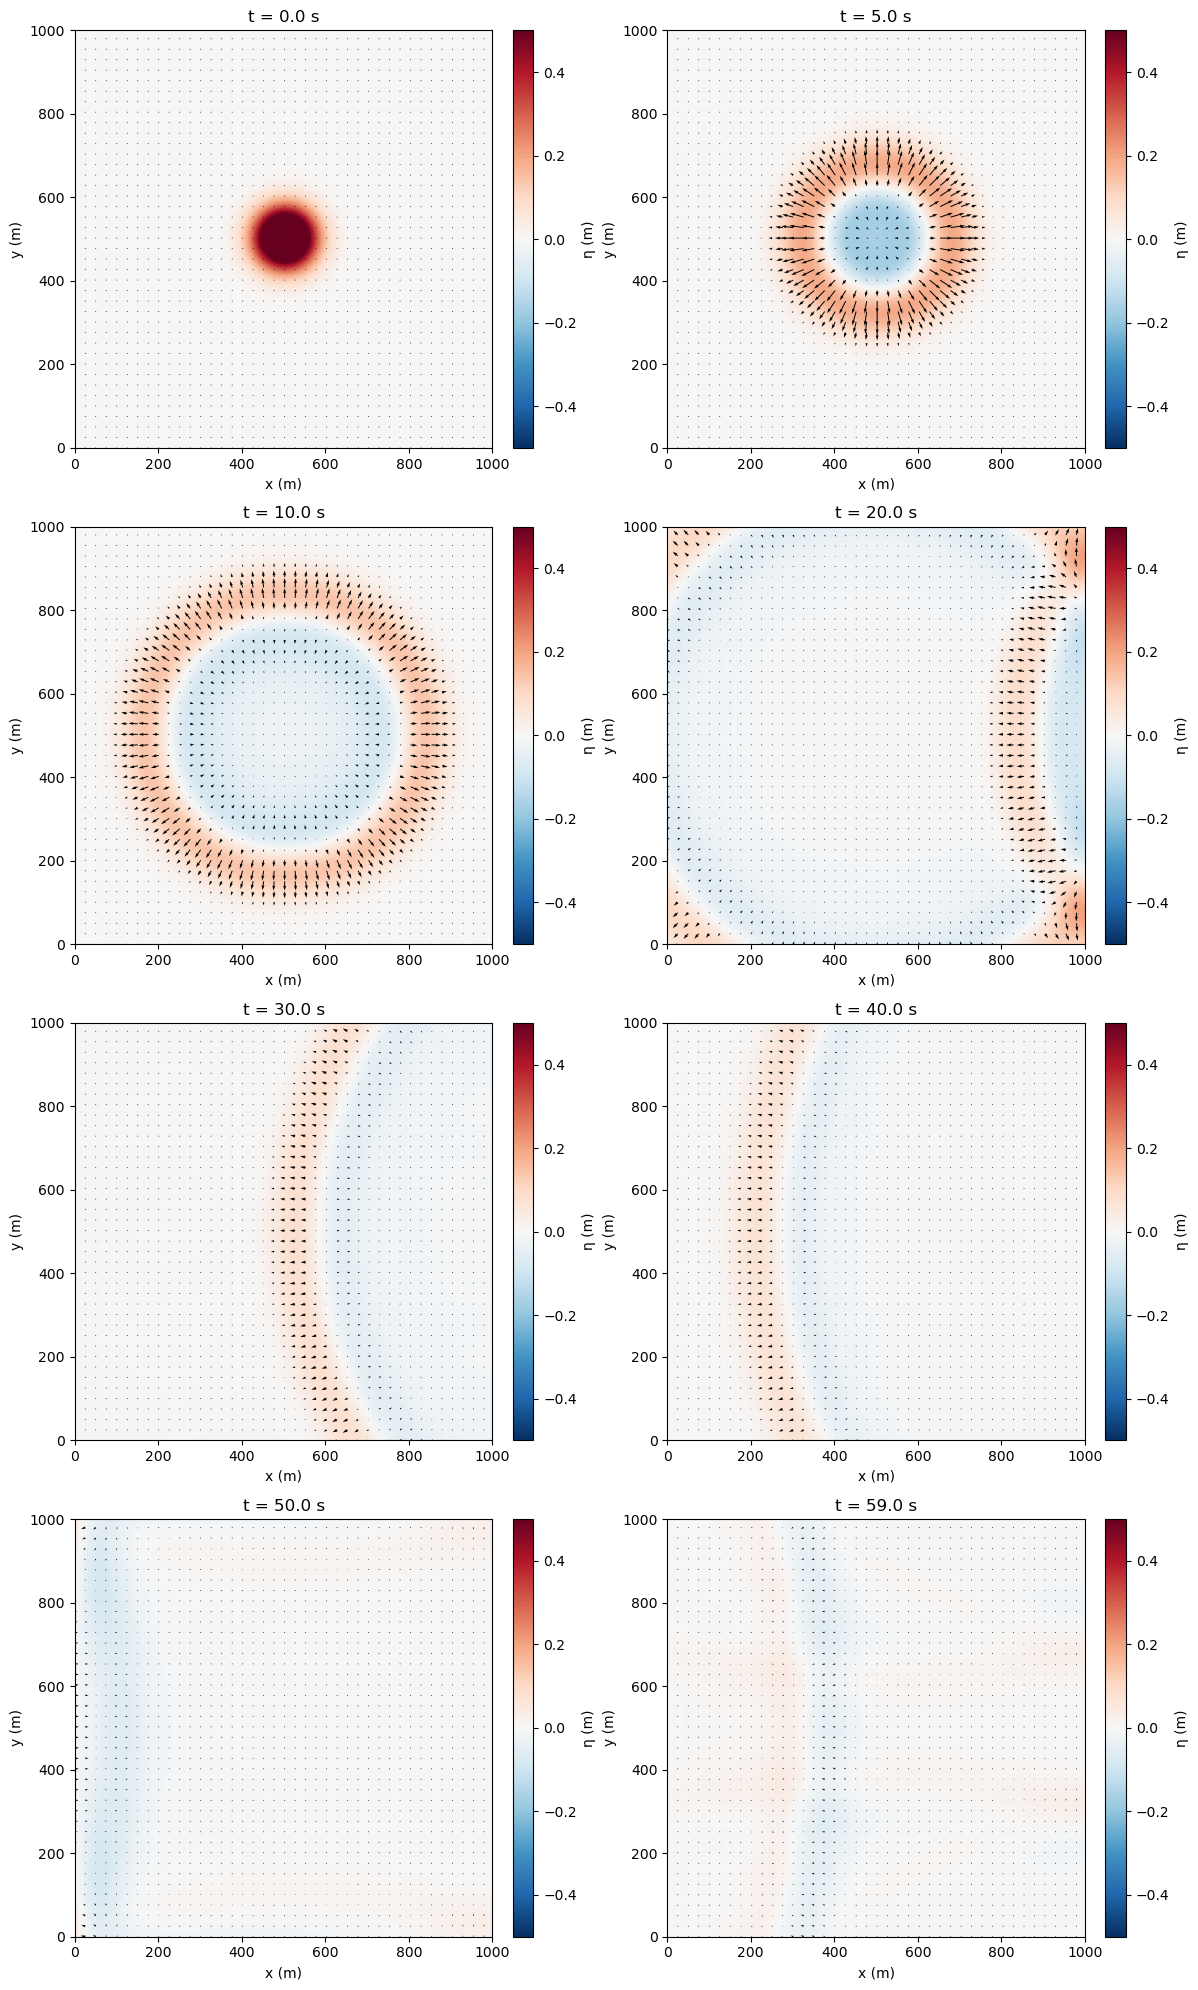

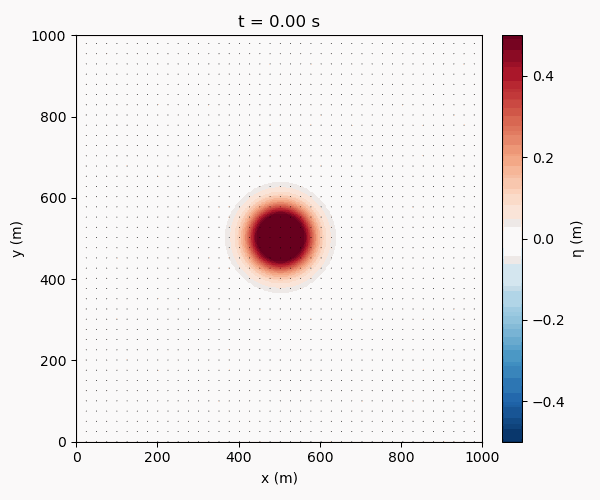

In [193]:
times_to_plot = [0, 5, 10, 20, 30, 40, 50, 59]
plot_eta_uv_2D(eta, u, v, xrange, yrange, dt, times_to_plot, skip=5, scale=2, ncols=2)
gif_eta_uv_2D(eta, u, v, xrange, yrange, dt, step=5, fps=4, skip=5, scale=2)

This 2D implementation allows the shallow water equations to be successfully extended to a coastal-like configuration, combining an open ocean boundary with a perfectly reflective wall. The numerical solution remains very stable, similarly to the 1D case. Although slight perturbations can still be observed near the end of the simulation, their amplitude remains very small and does not compromise the overall accuracy or physical relevance of the results.

# $\textcolor{blue}{Discussion\ and\ Conclusion}$

In this project, the shallow water equations were investigated through a systematic numerical study, starting from a one-dimensional configuration and progressively extending the model to two dimensions. The primary objective was not only to solve the equations numerically, but also to assess the influence of numerical schemes, time stepping, and boundary conditions on the stability and physical relevance of the solution.

A first important outcome of this work is the clear sensitivity of the numerical solution to the choice of the time integration scheme. While the explicit Euler method provides a simple and intuitive baseline, it requires a very restrictive time step to satisfy stability constraints, resulting in a high computational cost. In contrast, the fourth-order Runge–Kutta (RK4) scheme allows for a significantly larger time step while maintaining excellent numerical stability and accuracy. This highlights the importance of higher order temporal schemes when simulating wave propagation problems over long time intervals.

The treatment of boundary conditions was shown to be a critical aspect of the numerical resolution. Periodic boundary conditions proved useful for validation and idealized test cases, but they lack realism for physical applications involving wave reflection or open boundaries. More realistic configurations, such as open ocean boundaries and impermeable or perfectly reflective walls, were therefore introduced. These boundary conditions lead to small oscillations in both the velocity and the free surface elevation. However, these features should be interpreted as numerical perturbations induced by the boundary treatment rather than as genuine numerical instabilities. Their amplitude remains limited and does not compromise the overall quality of the solution.

Additional Neumann-type boundary conditions were explored to represent more realistic forcing scenarios, such as imposed surface slopes, velocity variations, or non-zero fluxes at the boundary. Although these configurations allow the modeling of physically meaningful situations, they do not completely eliminate the small perturbations observed previously. This indicates that boundary-induced disturbances are intrinsic to the numerical formulation and must be interpreted carefully, especially when using centered spatial discretizations.

The extension of the model to two dimensions represents a significant step toward more realistic geophysical applications. By combining an open ocean boundary with a perfectly reflective wall, a simplified coastal configuration was successfully reproduced. The 2D simulations exhibit a level of numerical stability comparable to the 1D case, confirming the robustness of the RK4-centered scheme. As in 1D, slight perturbations appear near the boundaries at later times, but their magnitude remains small and acceptable for the intended level of modeling.

From a methodological standpoint, several limitations of the present approach can be identified. First, the use of centered spatial discretizations, while simple and accurate for smooth solutions, is known to be weakly dissipative and can amplify boundary-related perturbations. The introduction of upwind or flux-limited schemes could improve robustness, particularly near boundaries. Second, the shallow water equations were considered in their linearized form, neglecting nonlinear advection terms, bottom topography, and friction. Including these effects would significantly enhance the physical realism of the model but would also impose stronger constraints on numerical stability.

Future work could therefore focus on extending the model to the fully nonlinear shallow water equations, implementing more advanced boundary treatments such as radiation conditions or characteristic-based methods, and incorporating realistic bathymetry. Additionally, adaptive time stepping or energy-conserving schemes could be investigated to further optimize the balance between accuracy and computational cost.

In conclusion, this study demonstrates that a centered fourth-order Runge–Kutta scheme provides an efficient and stable framework for solving the shallow water equations in both one and two dimensions. Despite the presence of small boundary-induced perturbations, the numerical solutions remain accurate and physically meaningful, making this approach well suited for idealized coastal and oceanic flow simulations.